In [24]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
dataset_dir = r"C:\Users\priya\project\filtre"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = r"C:\Users\priya\project\filtre\train"
val_dir = r"C:\Users\priya\project\filtre\val"
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 7888 images belonging to 2 classes.
Found 2252 images belonging to 2 classes.


In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(train_gen, validation_data=val_gen, epochs=10)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 855s 3s/step - accuracy: 0.9986 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 2.7808e-04
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 740s 3s/step - accuracy: 1.0000 - loss: 4.4747e-04 - val_accuracy: 0.9996 - val_loss: 7.5876e-04
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 741s 3s/step - accuracy: 0.9986 - loss: 0.0029 - val_accuracy: 0.9991 - val_loss: 0.0017
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 735s 3s/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 7.7907e-04
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 759s 3s/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 6.5853e-05
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - accuracy: 1.0000 - loss: 4.3663e-04 - val_accuracy: 1.0000 - val_loss: 4.4227e-05
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 222s 898ms/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 4.7063e-05
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accurac

In [13]:
from tensorflow.keras.optimizers import Adam
initial_epochs = 10
fine_tune_epochs = 5
total_epochs = initial_epochs + fine_tune_epochs
base_model.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),loss='binary_crossentropy',metrics=['accuracy'])
model.fit(train_gen,validation_data=val_gen,epochs=total_epochs,initial_epoch=initial_epochs)

Epoch 11/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 462s 2s/step - accuracy: 0.8685 - loss: 1.0337 - val_accuracy: 0.9996 - val_loss: 0.0025
Epoch 12/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.9963 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 7.1610e-05
Epoch 13/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - accuracy: 0.9970 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 2.9470e-05
Epoch 14/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.9973 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 1.7993e-04
Epoch 15/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 0.9996 - val_loss: 4.6601e-04


In [ ]:
test_dir = r"C:\Users\priya\project\filtre\test"
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(test_dir,target_size=(224, 224),batch_size=32,class_mode='binary',shuffle=False)

Found 1125 images belonging to 2 classes.


In [16]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 791ms/step - accuracy: 1.0000 - loss: 2.9836e-04
Test Accuracy: 1.0000, Test Loss: 0.0005


In [17]:
model.save("filtre.keras")

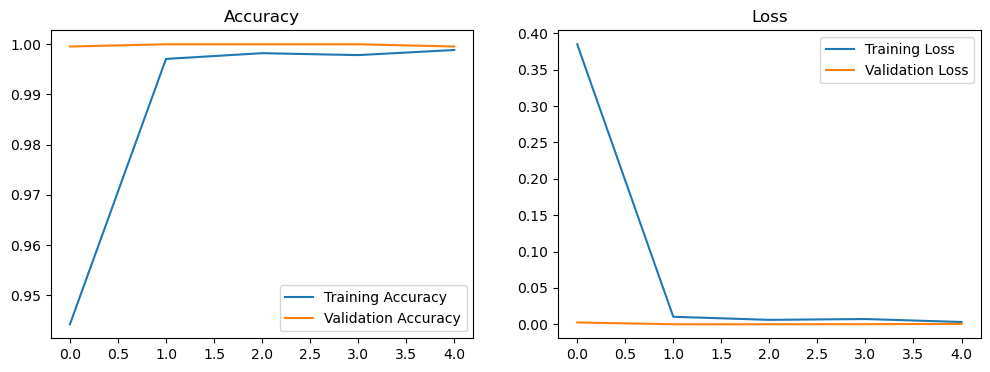

In [18]:
import matplotlib.pyplot as plt
history = model.history  
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 540ms/step
              precision    recall  f1-score   support

Not tea leaf       1.00      1.00      1.00       598
    Tea leaf       1.00      1.00      1.00       527

    accuracy                           1.00      1125
   macro avg       1.00      1.00      1.00      1125
weighted avg       1.00      1.00      1.00      1125



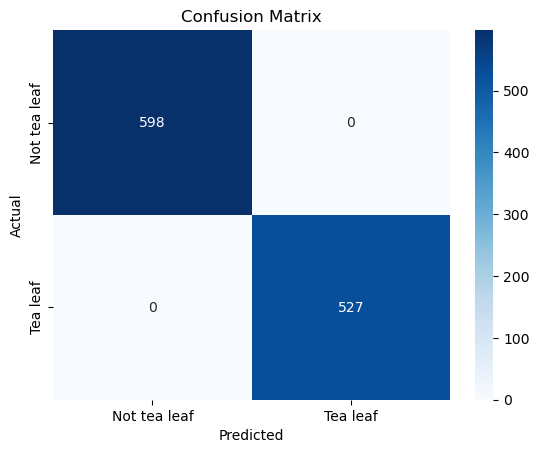

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
y_pred = (model.predict(test_gen) > 0.5).astype("int32").flatten()
y_true = test_gen.classes
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_gen.class_indices, yticklabels=test_gen.class_indices)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from PIL import Image

C:\Users\Asus\anaconda3\envs\tf310\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
model = load_model("filtre.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [3]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)
    predicted_class = 1 if pred[0][0] > 0.5 else 0 
    return predicted_class, pred[0][0]


In [4]:
class_labels = {0: "Not tea leaf", 1: "Tea leaf"}

In [5]:
def predict_and_display(img_path):
    pred_class, confidence = predict_image(img_path)
    label = f"{class_labels[pred_class]} ({confidence*100:.1f}%)"
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(label, fontsize=14)
    plt.axis('off')
    plt.show()
    print(f"Predicted class: {class_labels[pred_class]} with confidence {confidence*100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


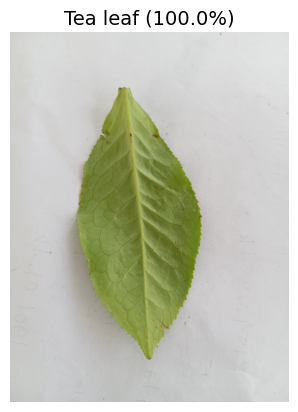

Predicted class: Tea leaf with confidence 100.0%


In [ ]:
img_path = r"C:\Users\priya\project\TeaDs\test\7. Healthy leaf\healthy_00109.jpg"
predict_and_display(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


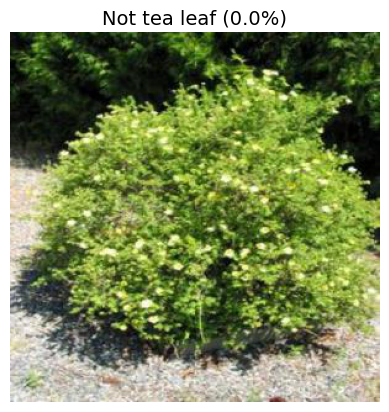

Predicted class: Not tea leaf with confidence 0.0%


In [ ]:
img_path = r"C:\Users\priya\project\filtre\test\Not tea leaf\9efae31575908a37f3d8779e0c6022b0-bush-plant-shrubs_jpg.rf.177b676c368f06aac9a0bb1fc59238b5.jpg"
predict_and_display(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


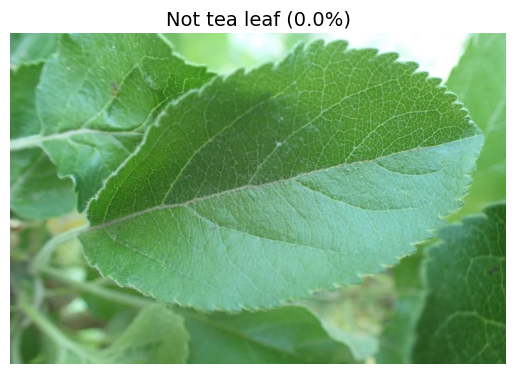

Predicted class: Not tea leaf with confidence 0.0%


In [ ]:
img_path = r"C:\Users\priya\project\filtre\test\Not tea leaf\9fe174c9e157850a.jpg"
predict_and_display(img_path)